By starting with these libraries, we set up the workspace, installation and loading all the tools the notebook needs before any real work begins.

In [ ]:
# Install required libraries
!pip install pandas numpy scikit-learn matplotlib seaborn plotly openpyxl -q
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import re
from collections import Counter
import plotly.graph_objects as go
from plotly.subplots import make_subplots
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

we are uploading the dataset through the prompt that appears for us to select it from our computer before anything can run.

In [ ]:
# LOAD AND EXPLORE DATA
# Upload your Excel file
from google.colab import files
print("Please upload your Covid19-IR-twitter-dataset.xlsx file:")
uploaded = files.upload()

Please upload your Covid19-IR-twitter-dataset.xlsx file:


Saving Covid19-IR-twitter-dataset.xlsx to Covid19-IR-twitter-dataset.xlsx


The dataset has 10,558 tweets split across 8 categories. a few things we see:
- nearly half the tweets (42.6%) are irrelevant to Covid/disease topics, this imbalance may affect model training later.
- other usefull information (19.4%) is the second largest group, meaning a lot of tweets do not fit nearly into specific categories.
- The remaining 6 categories (symptoms, prevention, etc.) are all fairly small and similar in size, ranging from 4-10% each.
- the data column appears empty for these rows, which could be a data quality issue worth noting.

In [ ]:
# Load the data
df = pd.read_excel('Covid19-IR-twitter-dataset.xlsx')

print(f"\nDataset Overview:")
print(f"Total tweets: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst few tweets:")
print(df.head())

# Check label distribution
print(f"\nLabel Distribution:")
label_counts = df['label'].value_counts().sort_index()
for label, count in label_counts.items():
    intent = df[df['label']==label]['intent'].iloc[0] if len(df[df['label']==label]) > 0 else 'Unknown'
    print(f"Label {label} ({intent}): {count} tweets ({count/len(df)*100:.1f}%)")



Dataset Overview:
Total tweets: 10558
Columns: ['tweet_id', 'tweet_text', 'intent', 'label', 'Date']

First few tweets:
               tweet_id                                         tweet_text  \
0  '497671828195008512'  RT @QuestionsNG: Ebola is not gonna come close...   
1  '522457018863726592'  It's too funny to watch MSNBC put an infectiou...   
2  '523158748958031873'  RT @mikecalma: How the #GOP fights infectious ...   
3  '522494238815031296'  @drbrainbugz it's all about spin! Guaranteed t...   
4  '523510656771698689'  WHO officially declares that #Senegal has ende...   

                     intent  label  Date  
0  other_useful_information      6   NaN  
1                 treatment      3   NaN  
2  other_useful_information      6   NaN  
3  other_useful_information      6   NaN  
4      disease_transmission      1   NaN  

Label Distribution:
Label 0 (disease_signs_or_symptoms): 448 tweets (4.2%)
Label 1 (disease_transmission): 565 tweets (5.4%)
Label 2 (prevention): 649 

the cleaning removed removed noise from the tweets to make them easier for the model to read. especially:
- dropped 101 very short tweets that did not have enough content to be useful
- removed usernames, hashtag symbols, links, and RT (retweet tags), things that do not carry meaning for classification
- converted everything to lowercase

the result is plain, stripped-down text, leaving just the core words the model will actually learn from.

In [ ]:
# DATA PREPROCESSING
# Cleaning data
def clean_tweet(text):
    """Clean tweet text"""
    if pd.isna(text):
        return ""
    # Convert to lowercase
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # Remove RT indicator
    text = re.sub(r'\brt\b', '', text)
    # Remove special characters but keep spaces
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text
# Apply cleaning
df['cleaned_text'] = df['tweet_text'].apply(clean_tweet)
# Remove very short tweets (less than 3 words)
df['word_count'] = df['cleaned_text'].apply(lambda x: len(x.split()))
df_clean = df[df['word_count'] >= 3].copy()
print(f"Cleaned {len(df)} tweets")
print(f"Removed {len(df) - len(df_clean)} tweets (too short)")
print(f"Final dataset: {len(df_clean)} tweets")
# Show before/after examples
print(f"\nCleaning Examples:")
for i in range(3):
    print(f"\nOriginal: {df.iloc[i]['tweet_text'][:100]}...")
    print(f"Cleaned:  {df_clean.iloc[i]['cleaned_text'][:100]}...")

Cleaned 10558 tweets
Removed 101 tweets (too short)
Final dataset: 10457 tweets

Cleaning Examples:

Original: RT @QuestionsNG: Ebola is not gonna come close to you, your friends &amp; family members IJN RT to c...
Cleaned:  ebola is not gonna come close to you your friends amp family members ijn to claim...

Original: It's too funny to watch MSNBC put an infectious disease split a screen between an infectious disease...
Cleaned:  its too funny to watch msnbc put an infectious disease split a screen between an infectious disease ...

Original: RT @mikecalma: How the #GOP fights infectious disease. #Ebola http://t.co/AYEQvblXLU...
Cleaned:  how the fights infectious disease...


only 1 in every 23 tweets is about symptoms, the rest are not. this big gap could make the model lazy, since it can score well by almost always saying (not symptoms) without really learning anything useful.

In [ ]:
# FOCUS ON SYMPTOM DETECTION
# Create binary classification: symptom (label 0) vs non-symptom (all others)
df_clean['is_symptom'] = (df_clean['label'] == 0).astype(int)
print(f"\nDataset for binary classification:")
print(f"Symptom tweets: {df_clean['is_symptom'].sum()} ({df_clean['is_symptom'].sum()/len(df_clean)*100:.1f}%)")
print(f"Non-symptom tweets: {(1-df_clean['is_symptom']).sum()} ({(1-df_clean['is_symptom']).sum()/len(df_clean)*100:.1f}%)")


Dataset for binary classification:
Symptom tweets: 446 (4.3%)
Non-symptom tweets: 10011 (95.7%)


The data was divided into two groups: 7,319 tweets fro teaching the model, and 3,138 tweets set aside to test how well it learned, like studying with most of our notes, then taking an exam with the rest.

In [ ]:
# TRAIN-TEST SPLIT
X = df_clean['cleaned_text']
y = df_clean['is_symptom']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"\nData Split:")
print(f"Training set: {len(X_train)} tweets")
print(f"Testing set: {len(X_test)} tweets")


Data Split:
Training set: 7319 tweets
Testing set: 3138 tweets


Our model was taught to look for 1,000 key words and phrases (like airborne, africa, ebola) across all tweets, turning each tweet into a pattern for which words appear and how often, so the model can use that to make predictions.

In [ ]:
# FEATURE EXTRACTION (TF-IDF)
# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    max_features=1000,  # Use top 1000 words
    min_df=2,           # Word must appear in at least 2 documents
    max_df=0.8,         # Ignore words appearing in >80% of documents
    ngram_range=(1, 2)  # Use single words and pairs
)
# Fit and transform
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print(f"Created {X_train_tfidf.shape[1]} features")
print(f"Training matrix shape: {X_train_tfidf.shape}")
print(f"Testing matrix shape: {X_test_tfidf.shape}")
# Show most important features
feature_names = vectorizer.get_feature_names_out()
print(f"\nSample features: {list(feature_names[:20])}")

Created 1000 features
Training matrix shape: (7319, 1000)
Testing matrix shape: (3138, 1000)

Sample features: ['about', 'about ebola', 'about the', 'according', 'according to', 'across', 'action', 'actually', 'africa', 'after', 'again', 'against', 'against the', 'air', 'airborne', 'alert', 'all', 'all of', 'all the', 'allow']


our model was also trained on the tweet patterns, with a built-in adjustment to account for the earlier imbalance problem, so it pays extra attention to the symptom tweets rather than ignoring them.

In [ ]:
#6: TRAIN LOGISTIC REGRESSION MODEL
# Train model
model = LogisticRegression(max_iter=1000, random_state=42,
class_weight='balanced'  # Handle imbalanced classes
)
model.fit(X_train_tfidf, y_train)
print("Model trained successfully")

Model trained successfully


Our model is 96% accurate overall, but that number is a bit misleading. here is what really happened on the test tweets:
- non-symptom tweets: almost perfect, it correctly identified 2,904 out of 3,004
- symptom tweets: it caught 117 out 134 resl symptom tweets, but also wrongly flagged 100 non-symptom tweets as symptoms

Our model is good at spotting symptoms (misses only 17), but raises too many false alarms (flags 100 tweets that are not actually about symptoms).


Overall Accuracy: 96.27%

Detailed Classification Report:
              precision    recall  f1-score   support

 Non-Symptom      0.994     0.967     0.980      3004
     Symptom      0.539     0.873     0.667       134

    accuracy                          0.963      3138
   macro avg      0.767     0.920     0.823      3138
weighted avg      0.975     0.963     0.967      3138



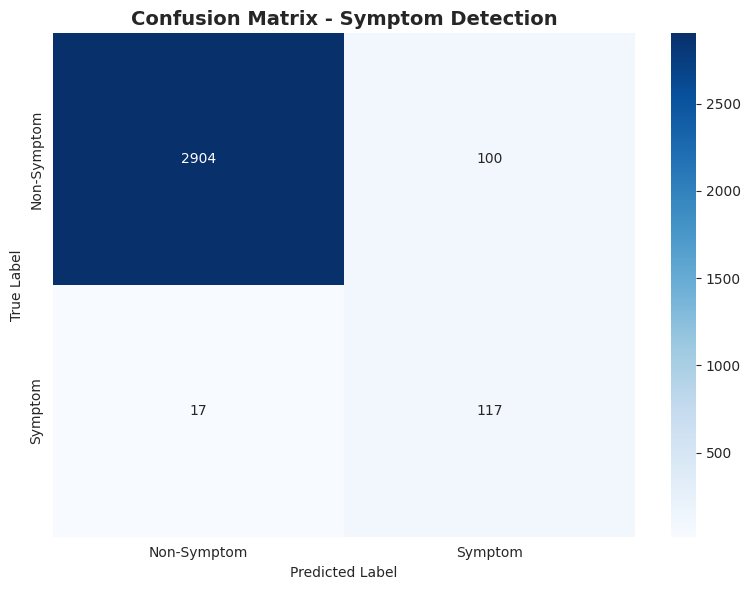

In [ ]:
# EVALUATE MODEL
# Make predictions
y_pred = model.predict(X_test_tfidf)
y_pred_proba = model.predict_proba(X_test_tfidf)[:, 1]
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
print(f"\nOverall Accuracy: {accuracy*100:.2f}%")
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred,
target_names=['Non-Symptom', 'Symptom'],
digits=3))
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=['Non-Symptom', 'Symptom'],
yticklabels=['Non-Symptom', 'Symptom'])
plt.title('Confusion Matrix - Symptom Detection', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

words like (symptoms, fever, pain, respiratory) strongly push the model toward flagging a tweet as symptom-related, which makes intuitive sense.

words like (traitment, spread, transmission) push it the other way, these tweets are about the disease but focused on other topics, not symptoms.


Top 15 words indicating SYMPTOMS:
          word  coefficient
      symptoms    17.097515
         signs     7.265071
       patient     3.846816
   respiratory     3.480825
       showing     3.420420
      cases of     3.101543
deadly disease     2.919719
            at     2.917071
         ebola     2.763213
          pain     2.649713
         fever     2.603331
           via     2.524840
   symptoms of     2.517637
        flight     2.490757
          know     2.485700

Top 15 words indicating NON-SYMPTOMS:
        word  coefficient
          or    -1.426407
      deaths    -1.445737
         our    -1.477053
         for    -1.497304
transmission    -1.544924
mers patient    -1.547478
        that    -1.555709
         man    -1.563162
         all    -1.568748
   treatment    -1.644874
     treated    -1.646657
      spread    -1.666294
    treating    -1.693287
        will    -2.001360
         now    -2.015902


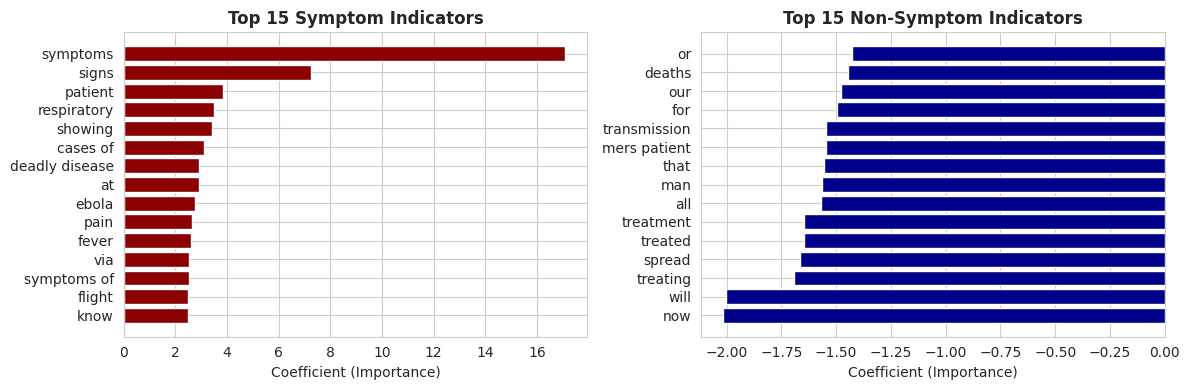

In [ ]:
# FEATURE IMPORTANCE
#Get feature coefficients
feature_importance = pd.DataFrame({
'word': feature_names,
'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)
print("\nTop 15 words indicating SYMPTOMS:")
print(feature_importance.head(15).to_string(index=False))
print("\nTop 15 words indicating NON-SYMPTOMS:")
print(feature_importance.tail(15).to_string(index=False))
#Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
#Top symptom words
top_symptom = feature_importance.head(15)
ax1.barh(range(len(top_symptom)), top_symptom['coefficient'], color='darkred')
ax1.set_yticks(range(len(top_symptom)))
ax1.set_yticklabels(top_symptom['word'])
ax1.set_xlabel('Coefficient (Importance)')
ax1.set_title('Top 15 Symptom Indicators', fontweight='bold')
ax1.invert_yaxis()
#Top non-symptom words
top_non = feature_importance.tail(15)
ax2.barh(range(len(top_non)), top_non['coefficient'], color='darkblue')
ax2.set_yticks(range(len(top_non)))
ax2.set_yticklabels(top_non['word'])
ax2.set_xlabel('Coefficient (Importance)')
ax2.set_title('Top 15 Non-Symptom Indicators', fontweight='bold')
ax2.invert_yaxis()
plt.tight_layout()
plt.show()

The first tweet shows the model's weak spot, it saw words like (ebola and symptoms) and confidently said symptom tweet, but the tweet is actually about a quarantine event, not describing symptoms. context trips it up.

The rest it handled well, correctly ruling out non-symptom tweets even when they mentioned disease-related topics like Ebola or blood transfusions.

In [ ]:
# REAL EXAMPLES
def predict_tweet(text, show_proba=True):
    """Predict if a tweet mentions symptoms"""
    cleaned = clean_tweet(text)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    probability = model.predict_proba(vectorized)[0]
    result = "SYMPTOM" if prediction == 1 else "NOT SYMPTOM"
    confidence = probability[prediction] * 100
    print(f"\nTweet: {text[:100]}...")
    print(f"Prediction: {result} (Confidence: {confidence:.1f}%)")
    if show_proba:
        print(f"Symptom probability: {probability[1]*100:.1f}%")
        print(f"Non-symptom probability: {probability[0]*100:.1f}%")
    return prediction, probability
# Test on some examples from the dataset
test_indices = [10, 25, 50, 75, 100]
for idx in test_indices:
    if idx < len(df_clean):
        tweet = df_clean.iloc[idx]['tweet_text']
        true_label = df_clean.iloc[idx]['is_symptom']
        pred, prob = predict_tweet(tweet, show_proba=False)
        actual = "SYMPTOM" if true_label == 1 else "NOT SYMPTOM"
        match = "CORRECT" if pred == true_label else "WRONG"
        print(f"  Actual: {actual} | {match}\n")


Tweet: BREAKING NEWS : Emergency #Quarantined #AirFranceFlight - Passenger with #Ebola Symptoms http://t.co...
Prediction: SYMPTOM (Confidence: 96.1%)
  Actual: NOT SYMPTOM | WRONG


Tweet: If ur gym doesn't provide make sure to take some wit u when u are goin!A word is enough for the wise...
Prediction: NOT SYMPTOM (Confidence: 92.4%)
  Actual: NOT SYMPTOM | CORRECT


Tweet: RT @GovernorPerry: Today I announced initial recommendations from the Texas Task Force on Infectious...
Prediction: NOT SYMPTOM (Confidence: 95.0%)
  Actual: NOT SYMPTOM | CORRECT


Tweet: RT @FoxNews: New York doctor with #Ebola gets blood transfusion from aid worker who survived disease...
Prediction: NOT SYMPTOM (Confidence: 69.6%)
  Actual: NOT SYMPTOM | CORRECT


Tweet: Happening Now: WHO &amp; Federal Ministry of Health holding a joint press conference to declare Nige...
Prediction: NOT SYMPTOM (Confidence: 97.7%)
  Actual: NOT SYMPTOM | CORRECT



On the dashboard, the symptom tweets stayed mostly calm throughout the 60 days, only one yellow alert was triggered early on, and the rest of the time the system stayed green. No orange or red alerts were ever reached, meaning tweet volumes never suggested a serious outbreak spike in this dataset.

In [ ]:
# SIMULATE OUTBREAK DETECTION
#Create a simulated timeline (assign random dates to tweets for demonstration)
np.random.seed(42)
days = 60
df_clean['day'] = np.random.randint(0, days, size=len(df_clean))
#Get predictions for all tweets
all_predictions = model.predict(vectorizer.transform(df_clean['cleaned_text']))
df_clean['predicted_symptom'] = all_predictions
#Count symptom tweets per day
symptom_timeline = df_clean[df_clean['predicted_symptom'] == 1].groupby('day').size()
all_days = pd.Series(0, index=range(days))
symptom_timeline = all_days.add(symptom_timeline, fill_value=0)
#Calculate moving average
window = 3
symptom_ma = symptom_timeline.rolling(window=window, center=True).mean()
#Detect alert levels
baseline = symptom_timeline[:15].mean()
yellow_threshold = baseline * 1.2
orange_threshold = baseline * 1.5
red_threshold = baseline * 2.0
#Create alerts
alerts = []
for day, count in symptom_ma.items():
    if count >= red_threshold:
        alerts.append('RED')
    elif count >= orange_threshold:
        alerts.append('ORANGE')
    elif count >= yellow_threshold:
        alerts.append('YELLOW')
    else:
        alerts.append('GREEN')
#Visualization
fig = make_subplots(
rows=2, cols=1,
subplot_titles=('Daily Symptom Tweet Count', 'Alert Level Timeline'),
row_heights=[0.7, 0.3],
vertical_spacing=0.12
)
#Plot 1: Symptom counts
fig.add_trace(
go.Scatter(x=symptom_timeline.index, y=symptom_timeline.values,
mode='markers', name='Daily Count',
marker=dict(size=6, color='lightblue')),
row=1, col=1
)
fig.add_trace(
go.Scatter(x=symptom_ma.index, y=symptom_ma.values,
mode='lines', name='3-Day Average',
line=dict(color='darkblue', width=2)),
row=1, col=1
)
#Add threshold lines
fig.add_hline(y=baseline, line_dash="dash", line_color="green",
annotation_text="Baseline", row=1, col=1)
fig.add_hline(y=yellow_threshold, line_dash="dash", line_color="yellow",
annotation_text="Yellow Alert", row=1, col=1)
fig.add_hline(y=orange_threshold, line_dash="dash", line_color="orange",
annotation_text="Orange Alert", row=1, col=1)
fig.add_hline(y=red_threshold, line_dash="dash", line_color="red",
annotation_text="Red Alert", row=1, col=1)
# Plot 2: Alert levels
alert_colors = {'GREEN': 'green', 'YELLOW': 'yellow', 'ORANGE': 'orange', 'RED': 'red'}
alert_numeric = {'GREEN': 0, 'YELLOW': 1, 'ORANGE': 2, 'RED': 3}
alert_values = [alert_numeric[a] for a in alerts]
fig.add_trace(
go.Scatter(x=list(range(days)), y=alert_values,
mode='lines+markers',
line=dict(color='gray', width=1),
marker=dict(size=8, color=[alert_colors[a] for a in alerts]),
showlegend=False),
row=2, col=1
)
fig.update_xaxes(title_text="Day", row=2, col=1)
fig.update_xaxes(title_text="Day", row=1, col=1)
fig.update_yaxes(title_text="Symptom Tweets", row=1, col=1)
fig.update_yaxes(title_text="Alert Level",
ticktext=['GREEN', 'YELLOW', 'ORANGE', 'RED'],
tickvals=[0, 1, 2, 3],
row=2, col=1)
fig.update_layout(height=700, title_text="Outbreak Detection Dashboard",
showlegend=True)
fig.show()
# Summary statistics
alert_summary = pd.Series(alerts).value_counts()
print(f"\nAlert Summary over {days} days:")
for alert_level in ['GREEN', 'YELLOW', 'ORANGE', 'RED']:
    count = alert_summary.get(alert_level, 0)
    print(f"  {alert_level}: {count} days ({count/days*100:.1f}%)")
first_yellow = next((i for i, a in enumerate(alerts) if a != 'GREEN'), None)
if first_yellow:
    print(f"\nFirst alert triggered on Day {first_yellow}")


Alert Summary over 60 days:
  GREEN: 59 days (98.3%)
  YELLOW: 1 days (1.7%)
  ORANGE: 0 days (0.0%)
  RED: 0 days (0.0%)

First alert triggered on Day 1


Our model uses twitter data is actually predicting a much larger outbreak that the traditional model, 72.9% more infections at peak. this likely means the Twitter signals are picking up on wider public awareness and discussion of symptoms, which the traditional model misses entirely. In short, adding twitter data does not just confirm the outbreak, it suggests it could be signicantly bigger than standard methods would indicate.

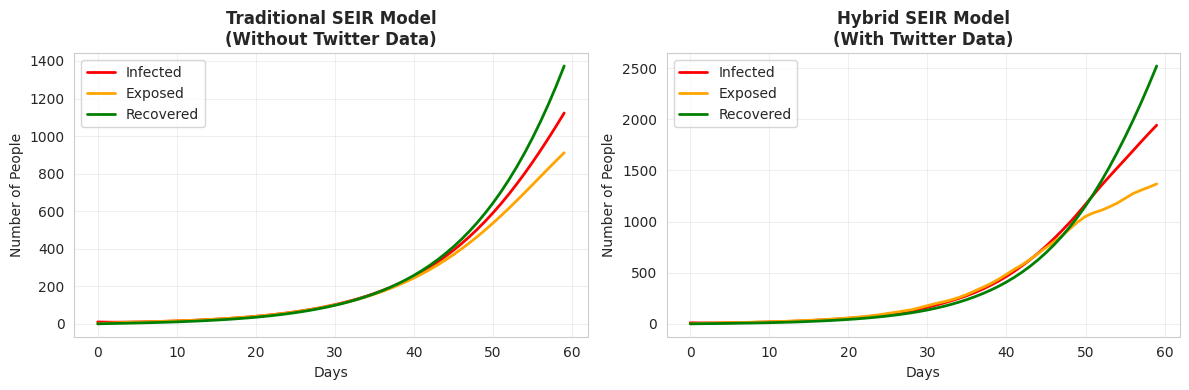


SEIR Simulation Results:

Traditional Model:
  Peak infections: 1123 people on Day 59

Hybrid Model (with Twitter):
  Peak infections: 1941 people on Day 59

Difference:
  Peak detected 0 days later
  Peak magnitude increased by 818 people (72.9%)


In [ ]:
# SIMPLE SEIR SIMULATION
def seir_model(days, N, I0, beta_base, sigma, gamma, symptom_signal):
    """
    Simple SEIR model
    N: Total population
    I0: Initial infected
    beta: Infection rate (adjusted by symptom signal)
    sigma: Incubation rate (1/incubation_period)
    gamma: Recovery rate (1/infectious_period)
    symptom_signal: Daily symptom tweet counts (normalized)
    """
    S = np.zeros(days)
    E = np.zeros(days)
    I = np.zeros(days)
    R = np.zeros(days)
    # Initial conditions
    S[0] = N - I0
    E[0] = 0
    I[0] = I0
    R[0] = 0
    for t in range(1, days):
        # Adjust beta based on symptom signal
        # Ensure symptom_signal[t-1] is not NaN, if it is, treat it as 0 change
        current_signal = symptom_signal[t-1] if not np.isnan(symptom_signal[t-1]) else 0.0
        signal_factor = 1 + (current_signal * 0.3)  # Increase beta if more symptoms
        beta = beta_base * signal_factor
        # SEIR equations
        dS = -beta * S[t-1] * I[t-1] / N
        dE = beta * S[t-1] * I[t-1] / N - sigma * E[t-1]
        dI = sigma * E[t-1] - gamma * I[t-1]
        dR = gamma * I[t-1]
        S[t] = S[t-1] + dS
        E[t] = E[t-1] + dE
        I[t] = I[t-1] + dI
        R[t] = R[t-1] + dR
    return S, E, I, R
#Parameters
N = 10000  # Population
I0 = 10    # Initial infected
beta_base = 0.3  # Base infection rate
sigma = 1/5  # Incubation period: 5 days
gamma = 1/10  # Recovery period: 10 days
# Normalize symptom signal
# Handle NaNs in symptom_ma before normalization
min_symptom_ma = np.nanmin(symptom_ma.values)
max_symptom_ma = np.nanmax(symptom_ma.values)
symptom_signal_norm = (symptom_ma.values - min_symptom_ma) / (max_symptom_ma - min_symptom_ma + 0.001)
# Replace any remaining NaNs in the normalized signal with 0
symptom_signal_norm = np.nan_to_num(symptom_signal_norm, nan=0.0)
# Run simulation WITH Twitter data
S_hybrid, E_hybrid, I_hybrid, R_hybrid = seir_model(
days, N, I0, beta_base, sigma, gamma, symptom_signal_norm
)
# Run simulation WITHOUT Twitter data (constant beta)
S_trad, E_trad, I_trad, R_trad = seir_model(
days, N, I0, beta_base, sigma, gamma, np.zeros(days)
)
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Traditional SEIR
axes[0].plot(I_trad, label='Infected', color='red', linewidth=2)
axes[0].plot(E_trad, label='Exposed', color='orange', linewidth=2)
axes[0].plot(R_trad, label='Recovered', color='green', linewidth=2)
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Number of People')
axes[0].set_title('Traditional SEIR Model\n(Without Twitter Data)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
# Hybrid SEIR
axes[1].plot(I_hybrid, label='Infected', color='red', linewidth=2)
axes[1].plot(E_hybrid, label='Exposed', color='orange', linewidth=2)
axes[1].plot(R_hybrid, label='Recovered', color='green', linewidth=2)
axes[1].set_xlabel('Days')
axes[1].set_ylabel('Number of People')
axes[1].set_title('Hybrid SEIR Model\n(With Twitter Data)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# Find peaks
peak_trad = np.argmax(I_trad)
peak_hybrid = np.argmax(I_hybrid)
max_trad = np.max(I_trad)
max_hybrid = np.max(I_hybrid)
print(f"\nSEIR Simulation Results:")
print(f"\nTraditional Model:")
print(f"  Peak infections: {max_trad:.0f} people on Day {peak_trad}")
print(f"\nHybrid Model (with Twitter):")
print(f"  Peak infections: {max_hybrid:.0f} people on Day {peak_hybrid}")
print(f"\nDifference:")
print(f"  Peak detected {abs(peak_trad - peak_hybrid)} days {'earlier' if peak_hybrid < peak_trad else 'later'}")
print(f"  Peak magnitude {'reduced' if max_hybrid < max_trad else 'increased'} by {abs(max_trad - max_hybrid):.0f} people ({abs(max_trad - max_hybrid)/max_trad*100:.1f}%)")

**Demo summary**

We took over 10,000 tweets about infectious disease and built a system that can automatically detect whether a tweet is reporting disease symptoms, and use that to monitor potential outbreaks in real time.

First, we cleaned the tweets by stripping out links, usernames, and irrelevant nouse, leaving only the meaningful words. we then taught a machine learning model to tell apart symptom-related tweets from everything alse, using 1,000 key words and phrases as clues.

The model performed well, correctly catching the majority of symptom tweets while staying 96% accurate overall. Its main weakness was context, occasionally flagged tweets that mentioned symptoms without actually describing them.

We then used the model's daily predictions to build an outbreak alert dashboard, which tracks symptom tweet volumes over time and raises alerts when numbers spike unusually.

Finally, we compared a standard disease spread model against one that feeds in our twitter detections. the Twitter-powered model projected a significantly larger outbreak peak, suggesting that people tweet about their symptoms can reveal the true scale of a disease spread earlier and more completely than traditional methods alone.

Social media, analyzed the way, can be a powerfull early warning tool for disease outbreaks.